<a href="https://colab.research.google.com/github/jiffy-jacob/deep-learning_diabetes_prediction/blob/main/deep_learning_diabetes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Deep Learning**
**Objective:**  
You are required to model the progression of diabetes using the available independent
variables. This model will help healthcare professionals understand how different factors
influence the progression of diabetes and potentially aid in designing better treatment
plans and preventive measures. The model will provide insights into the dynamics of
diabetes progression in patients.

**Dataset:**
Use the Diabetes dataset available in the sklearn library.


**1. Loading and Preprocessing**
* Load the Diabetes dataset from sklearn.  
* Handle any missing values if present.  
* Normalize the features to ensure better performance of the ANN model.

In [1]:
#Import Libraries
import numpy as np
import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Load dataset
diabetes=load_diabetes()
X=diabetes.data
y=diabetes.target
df=pd.DataFrame(X,columns=diabetes.feature_names)
df.head()


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [4]:
print(df.shape)
print(y.shape)
df.info()


(442, 10)
(442,)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
dtypes: float64(10)
memory usage: 34.7 KB


In [5]:
#checking missing values
df.isnull().sum()

,0
age,0
sex,0
bmi,0
bp,0
s1,0
s2,0
s3,0
s4,0
s5,0
s6,0


In [6]:
#normalize the features
#first we split the data since we do fit preprocessing on the training data only

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (353, 10)
X_test shape: (89, 10)


In [7]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

**2. Exploratory Data Analysis (EDA)**   
* Perform EDA to understand the distribution of features and the target
variable.  
* Visualize the relationships between features and the target variable.

In [8]:
#EDA
df.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01


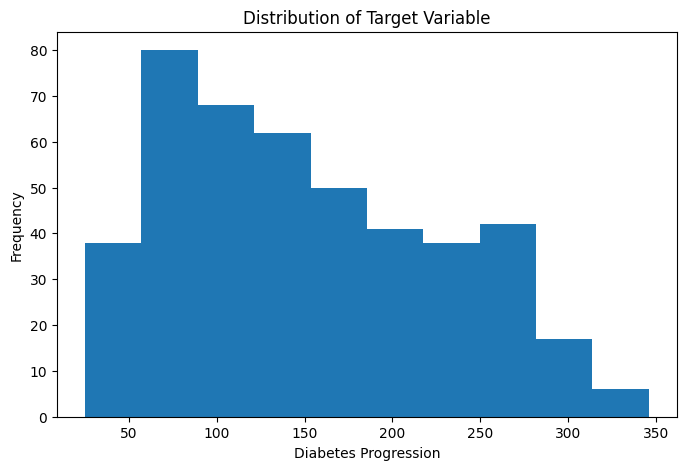

In [9]:
#Target Distribution
plt.figure(figsize=(8, 5))
plt.hist(y, bins=10)
plt.xlabel("Diabetes Progression")
plt.ylabel("Frequency")
plt.title("Distribution of Target Variable")
plt.show()

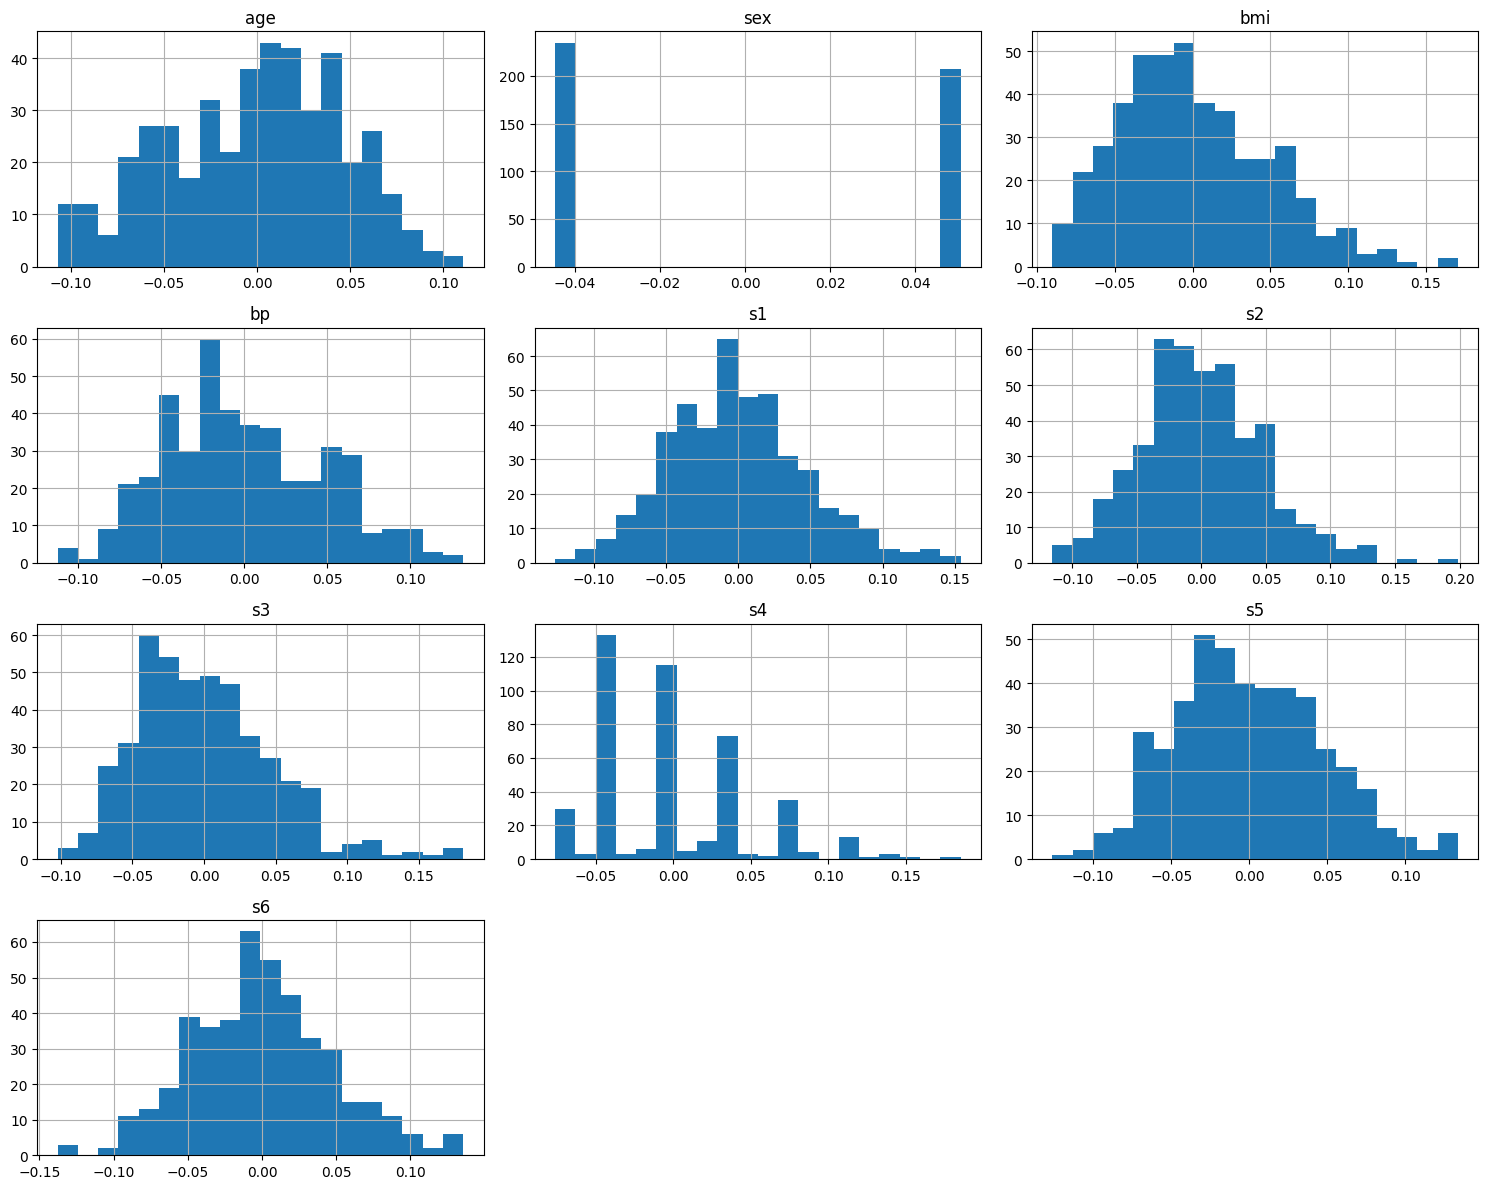

In [11]:
#Distribution of each feature
df.hist(figsize=(15, 12), bins=20)
plt.tight_layout()
plt.show()

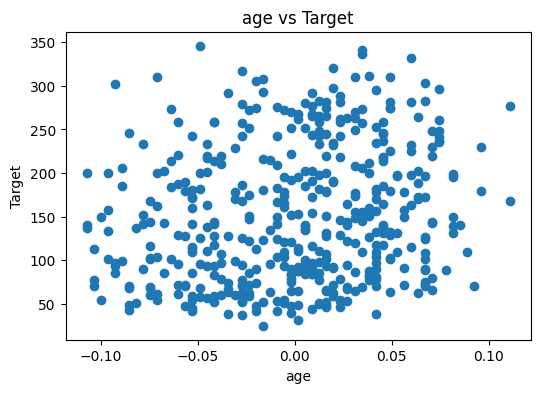

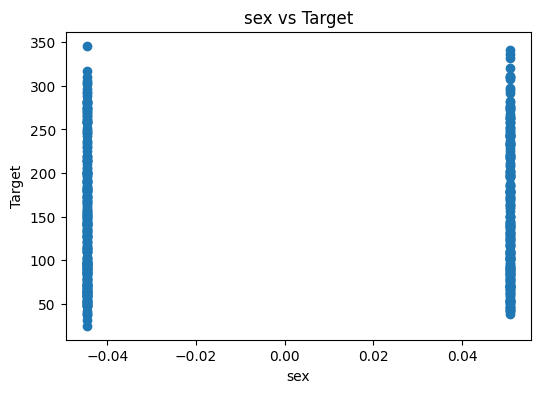

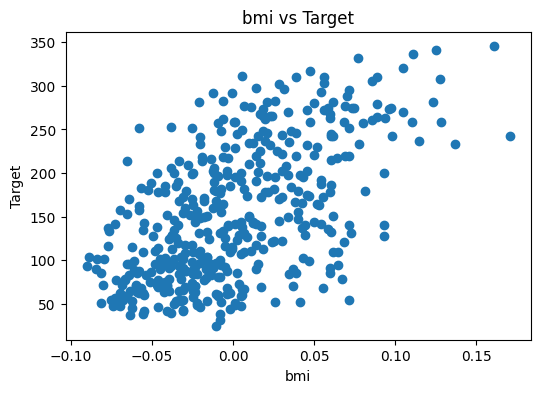

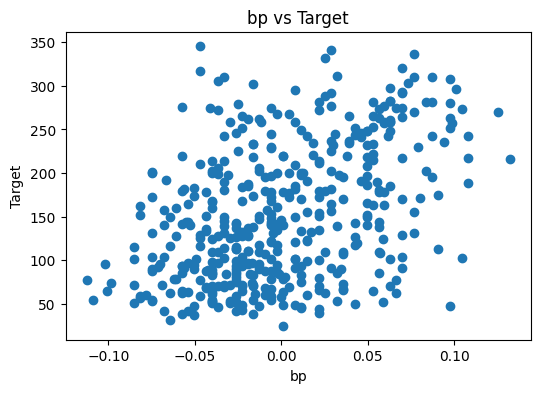

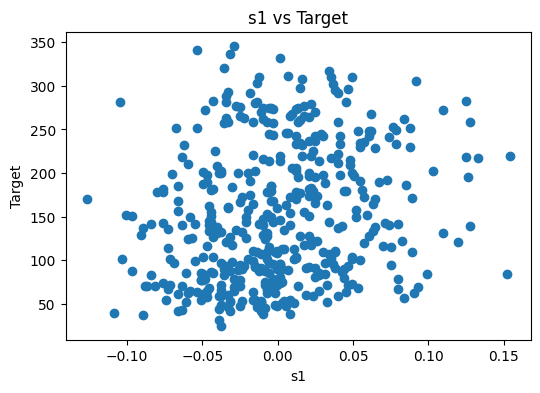

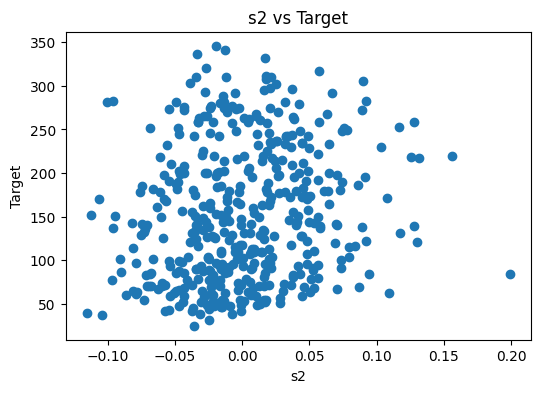

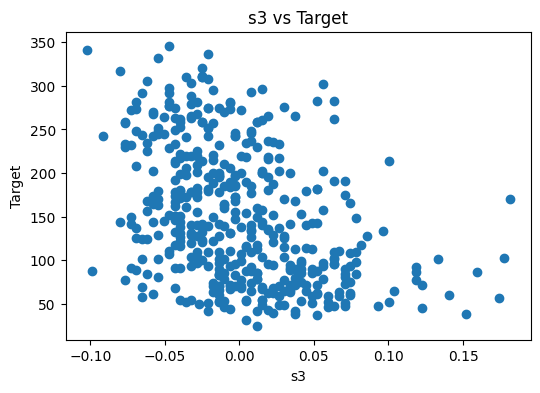

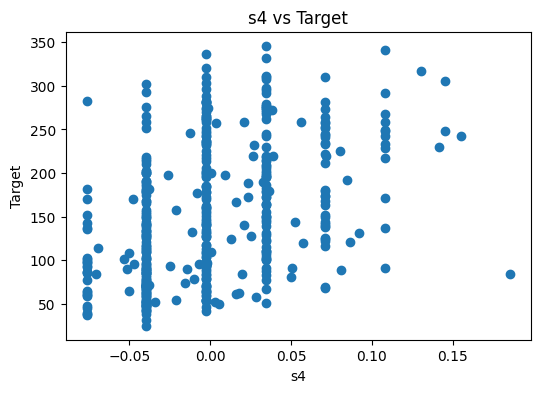

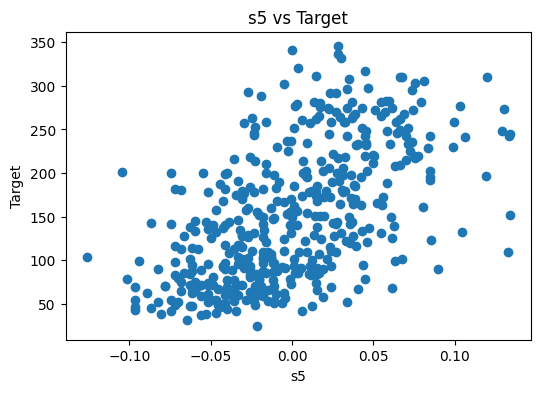

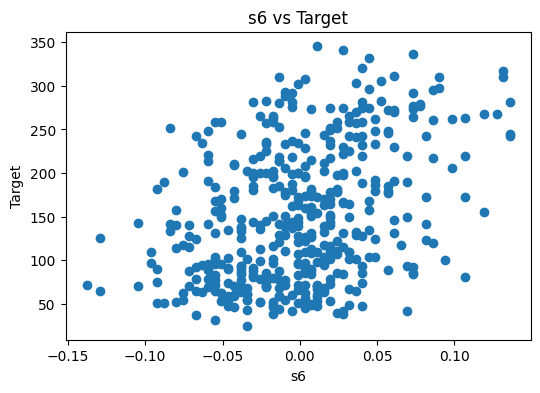

In [12]:
features = diabetes.feature_names
df['target']=y
for feature in features:
    plt.figure(figsize=(6, 4))
    plt.scatter(df[feature], df["target"])
    plt.xlabel(feature)
    plt.ylabel("Target")
    plt.title(f"{feature} vs Target")
    plt.show()

In [13]:
#Correlation with target
correlation = df.corr()["target"].sort_values(ascending=False)

print(correlation)

target    1.000000
bmi       0.586450
s5        0.565883
bp        0.441482
s4        0.430453
s6        0.382483
s1        0.212022
age       0.187889
s2        0.174054
sex       0.043062
s3       -0.394789
Name: target, dtype: float64


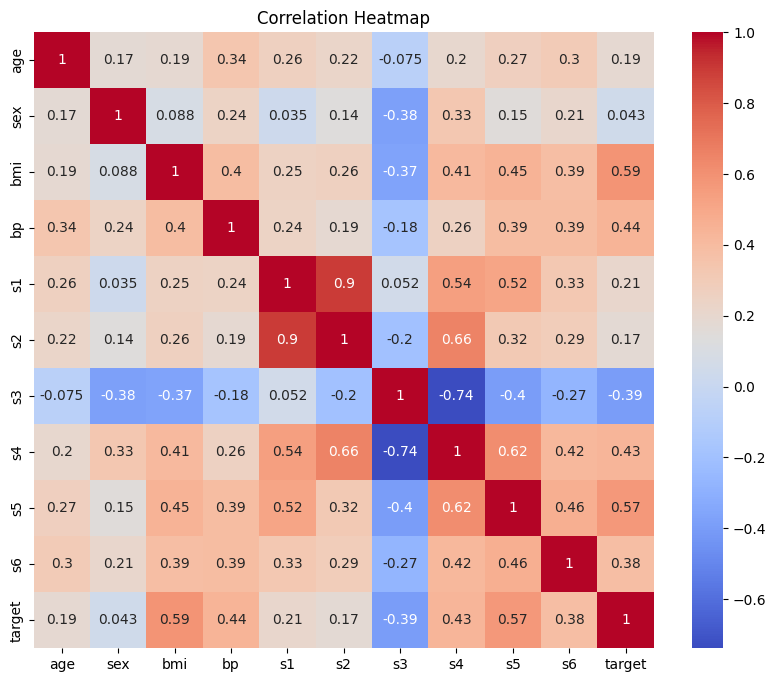

In [14]:
#correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

The Diabetes dataset contains 442 observations and 10 independent features. No missing values were found. The distributions of the features and target variable were examined using histograms, while scatter plots and correlation analysis were used to understand the relationships between the features and diabetes progression. These observations will help in preparing the data for the ANN model.

**3. Building the ANN Model**
* Design a simple ANN architecture with at least one hidden layer.  
* Use appropriate activation functions .

In [15]:
#Simple ANN
model = Sequential()

model.add(Dense(16, activation="relu", input_shape=(X_train.shape[1],)))
model.add(Dense(8, activation="relu"))
model.add(Dense(1, activation="linear"))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

In [17]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 321 (1.25 KB)

 Trainable params: 321 (1.25 KB)

 Non-trainable params: 0 (0.00 B)

ReLU in the hidden layers helps the network learn non-linear relationships. Linear activation function in the output layer is given as we are predicting a continuous numerical value, not a class.

**4. Training the ANN Model**
* Split the dataset into training and testing sets.  
* Train the model on the training data.  
* Use an appropriate loss function and optimizer.

In [18]:
#Train the model
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2,verbose=1)


Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 123ms/step - loss: 31393.0742 - mae: 158.5379 - val_loss: 22417.7070 - val_mae: 134.0662
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - loss: 31313.2051 - mae: 158.3179 - val_loss: 22356.9902 - val_mae: 133.8668
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - loss: 31229.1914 - mae: 158.0839 - val_loss: 22295.0781 - val_mae: 133.6634
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - loss: 31141.7402 - mae: 157.8445 - val_loss: 22229.4395 - val_mae: 133.4488
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 31049.2227 - mae: 157.5904 - val_loss: 22160.2051 - val_mae: 133.2250
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 30948.5176 - mae: 157.3154 - val_loss: 22084.8770 - val_mae: 132.9828
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - loss: 30835.3340 - mae: 157.0107 - val_loss: 22003.7598 - val_mae: 132.7210
Epoch 8/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 30716.4902 - mae: 156.6854 - val_loss: 21912.

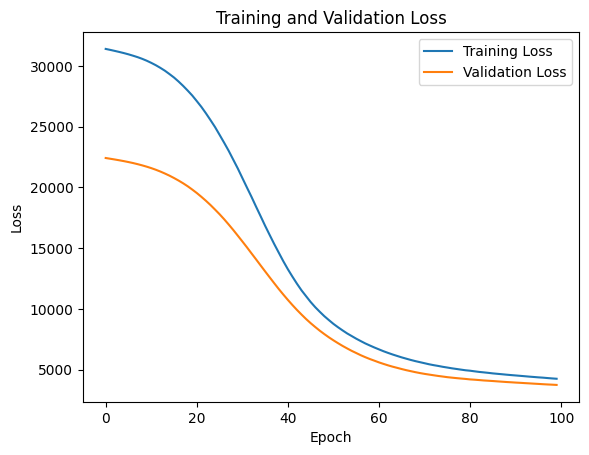

In [19]:
#plot training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title("Training and Validation Loss")
plt.legend()
plt.show()


In [20]:
print("Final Training Loss:", history.history["loss"][-1])
print("Final Validation Loss:", history.history["val_loss"][-1])

Final Training Loss: 4255.578125
Final Validation Loss: 3748.042236328125


**5. Evaluating the Model**  
* Evaluate the model on the testing data.  
* Report the performance metrics (e.g., Mean Squared Error, R² Score).

In [21]:
#Make Predictions
y_pred=model.predict(X_test)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


In [22]:
#Calculate MSE and R2score
mse=mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("Mean Squared Error:",mse)
print("R2 Score:",r2)
print("Mean Absolute Error:", mae)

Mean Squared Error: 4335.924767109775
R2 Score: 0.18161559484894618
Mean Absolute Error: 51.8156969734792


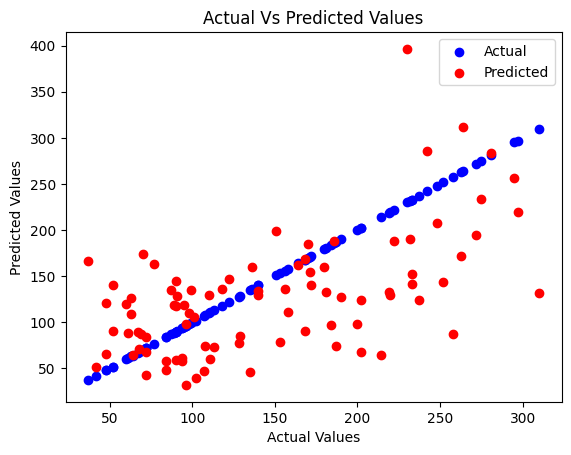

In [23]:
#Actual Vs Predicted values
plt.scatter(y_test, y_test, label="Actual", color="blue")
plt.scatter(y_test, y_pred.flatten(), label="Predicted", color="red")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual Vs Predicted Values")
plt.legend()
plt.show()

The trained ANN was evaluated using the unseen test dataset. Mean Squared Error (MSE), Mean Absolute Error (MAE), and R² Score were calculated to measure the regression performance. An actual-versus-predicted plot was also used to visually assess the model's predictions.

**6. Improving the Model**
* Experiment with different architectures, activation functions, or hyperparameters to improve the model performance.  
* Report the changes made and the corresponding improvement in performance.  

In [24]:
#Improved Model
improved_model = Sequential()
improved_model.add(Dense(32, activation="relu", input_shape=(X_train.shape[1],)))
improved_model.add(Dense(16, activation="relu"))
improved_model.add(Dropout(0.2))
improved_model.add(Dense(8, activation="relu"))
improved_model.add(Dense(1, activation="linear"))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [25]:
#Compile
improved_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

In [26]:
improved_history = improved_model.fit(
    X_train,
    y_train,
    epochs=150,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - loss: 31588.2988 - mae: 158.8432 - val_loss: 22484.3184 - val_mae: 134.0623
Epoch 2/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 31472.3945 - mae: 158.4982 - val_loss: 22388.5508 - val_mae: 133.7251
Epoch 3/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 31359.3965 - mae: 158.1620 - val_loss: 22294.3574 - val_mae: 133.3882
Epoch 4/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - loss: 31237.5781 - mae: 157.7942 - val_loss: 22188.7793 - val_mae: 133.0121
Epoch 5/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 31106.5781 - mae: 157.3769 - val_loss: 22063.6133 - val_mae: 132.5654
Epoch 6/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 30922.7402 - mae: 156.8506 - val_loss: 21910.8379 - val_mae: 132.0186
Epoch 7/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 30718.8652 - mae: 156.1951 - val_loss: 21714.9980 - val_mae: 131.3227
Epoch 8/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 30417.9922 - mae: 155.3178 - val_loss: 21466.9

# Model Improvement Comparison

| Parameter | Original ANN | Improved ANN |
|---|---|---|
| Architecture | 10 → 16 → 8 → 1 | 10 → 32 → 16 → 8 → 1 |
| Hidden Layers | 2 | 3 |
| Dropout | None | 20% |
| Epochs | 100 | 150 |
| Batch Size | 32 | 32 |
| Optimizer | Adam | Adam |
| Activation Function | ReLU | ReLU |
| Output Activation | Linear | Linear |

# Changes Made

* Increased the number of neurons.
* Added one additional hidden layer.
* Added 20% dropout to reduce overfitting.
* Increased epochs from 100 to 150.
* Kept the batch size, optimizer, and activation functions unchanged.

In [27]:
#Evaluate the Improved Model
improved_pred = improved_model.predict(X_test)

improved_mse = mean_squared_error(y_test, improved_pred)
improved_mae = mean_absolute_error(y_test, improved_pred)
improved_r2 = r2_score(y_test, improved_pred)

print("Improved Model Results")
print("MAE:", improved_mae)
print("MSE:", improved_mse)
print("R² Score:", improved_r2)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Improved Model Results
MAE: 43.21363821994053
MSE: 2893.348327090607
R² Score: 0.45389477983511906


In [28]:
#Comparison of both models
print("Original Model")
print("MAE:", mae)
print("MSE:", mse)
print("R²:", r2)

print("\nImproved Model")
print("MAE:", improved_mae)
print("MSE:", improved_mse)
print("R²:", improved_r2)

Original Model
MAE: 51.8156969734792
MSE: 4335.924767109775
R²: 0.18161559484894618

Improved Model
MAE: 43.21363821994053
MSE: 2893.348327090607
R²: 0.45389477983511906


In [29]:
comparison = pd.DataFrame({
    "Model": ["Original ANN", "Improved ANN"],
    "MAE": [mae, improved_mae],
    "MSE": [mse, improved_mse],
    "R2 Score": [r2, improved_r2]
})

comparison

,Model,MAE,MSE,R2 Score
0,Original ANN,51.815697,4335.924767,0.181616
1,Improved ANN,43.213638,2893.348327,0.453895


# Model Improvement Results

The original ANN model was improved by increasing the number of neurons, adding an additional hidden layer, introducing 20% dropout, and increasing the number of training epochs from 100 to 150.

| Metric | Original ANN | Improved ANN |
| ------ | -----------: | -----------: |
| MAE    |        51.81 |    **43.21** |
| MSE    |      4335.92 |  **2893.34** |
| R²     |       0.1816 |   **0.4538** |

# Improvement Observed

* MAE decreased from 51.81 to 43.21.
* MSE decreased from 4335.92 to 2893.34.
* R² increased from 0.1816 to 0.4538.
* The improved ANN therefore achieved lower prediction errors and a higher R² score than the original model.
* These results indicate that the architectural and training changes improved the model's performance on the test data.
